In [1]:
# ! pip install healpy numpyro corner arviz optax reproject einops seaborn chainconsumer blackjax

In [4]:
! nvidia-smi --query-gpu=name --format=csv,noheader

Tesla V100-PCIE-32GB


In [5]:
import sys
sys.path.append("../")

from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import corner
import matplotlib.pyplot as plt

from models.np_model import NPModel

%load_ext autoreload
%autoreload 2

/n/home11/smsharma/.local/lib/python3.8/site-packages/chex/_src/pytypes.py:37: FutureWarning: jax.tree_structure is deprecated, and will be removed in a future release. Use jax.tree_util.tree_structure instead.
  PyTreeDef = type(jax.tree_structure(None))


In [6]:
data = jnp.array(np.load("../data/fermi_data/fermidata_counts.npy").astype(np.int32))

In [7]:
npmodel = NPModel(data, dif="ModelO", vary_disk=False, bulge_hybrid=True, vary_gamma=True)

svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(4234), n_steps=5000)
arviz_post = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=50000)

Loading the psf correction from: /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/psf_dir/Fermi_PSF_2GeV2.npy


100%|██████████| 5000/5000 [02:08<00:00, 38.97it/s, init loss: 21459.0399, avg. loss [4751-5000]: 18989.6343]


In [8]:
posterior = arviz_post.to_dict()['posterior']

In [9]:
# hp.mollview(npmodel.temp_dsk)

In [10]:
# from models.templates import GaussianDiskTemplate
# import healpy as hp

# hp.mollview(GaussianDiskTemplate().get_gaussian_template(zs=1., sigma_r=1))

### Probabilistic model

/n/home11/smsharma/.local/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/n/home11/smsharma/.local/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


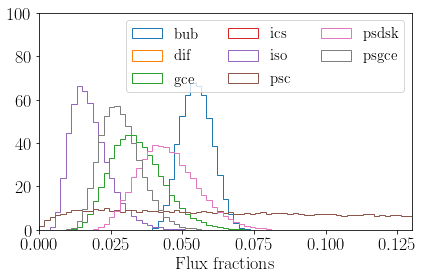

In [11]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])[:, 0, :]
S_labels = np.array([k for k,v in posterior.items() if k.startswith('S')])

flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]

ff_max = 0.13
ff_bins = 70

bins = np.linspace(0, ff_max, ff_bins)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", "")[1:], histtype='step', density=True)
    
plt.xlim(0, ff_max)
plt.ylim(0, 100)
plt.legend(ncol=3, fontsize=15)

plt.xlabel("Flux fractions")

plt.tight_layout()
# plt.savefig("prob_prog_results/ff_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

In [12]:
# import numpy as np
# from numpy.random import normal, random, multivariate_normal
# from chainconsumer import ChainConsumer


# data = np.array([flux_fraction_post[2], flux_fraction_post[7]]).T * 100
                 
# # If the parameters are the same between chains, you can just pass it the
# # first time, and they will become the default parameters.
# fig = ChainConsumer()\
#     .add_chain(data, parameters=[r"DM", r"PS"], name="Test chain")\
#     .plotter.plot()

In [13]:
# import seaborn as sns

# sns.kdeplot(data=flux_fraction_post.T)
# plt.xlim(0, ff_max)

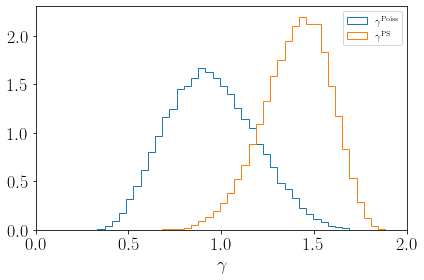

In [14]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('gamma')])[:, 0, :]
S_labels = [r"$\gamma^\mathrm{Poiss}$",r"$\gamma^\mathrm{PS}$"]

flux_fraction_post = S_post

bins = np.linspace(0.1, 2., 50)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True)
    
plt.legend()
plt.xlim(0, 2.)

plt.xlabel(r"$\gamma$")

plt.tight_layout()
# plt.savefig("prob_prog_results/gamma_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

In [16]:
# S_post = np.array([v for k,v in posterior.items() if k.startswith('zs')])[:, 0, :]

# flux_fraction_post = S_post

# bins = np.linspace(0.1, 1.5, 75)
# for i in range(len(flux_fraction_post)):
#     plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True)
    
# plt.xlabel("$z_\mathrm{s}$")

# plt.tight_layout()
# # plt.savefig("prob_prog_results/zs_dif_{}_r_{}_lmax_{}_x.pdf".format(dif, r_outer, lmax))

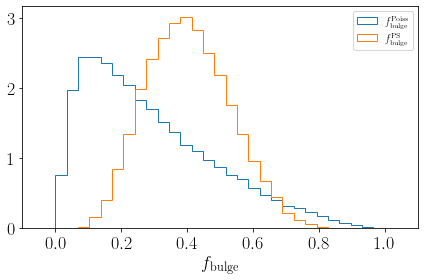

In [17]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('f_bulge')])[:, 0, :]
S_labels = [r"$f_\mathrm{bulge}^\mathrm{Poiss}$",r"$f_\mathrm{bulge}^\mathrm{PS}$"]

flux_fraction_post = S_post

bins = np.linspace(0., 1., 30)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i], histtype='step', density=True)
    
plt.xlim(-0.1, 1.1)
plt.legend()

plt.xlabel(r"$f_\mathrm{bulge}$")

plt.tight_layout()
# plt.savefig("prob_prog_results/fbulge_dif_{}_r_{}_lmax_{}.pdf".format(dif, r_outer, lmax))

In [189]:
# temps_include = ['Sps_gceps', 'S_gce', 'gamma_poiss', 'gamma_ps']
# S_post = np.array([v for k,v  in posterior.items()])
# S_labels = np.array([k for k,v  in posterior.items()])

# corner.corner(S_post.T, labels=[t.replace("_", "") for t in S_labels]);

In [305]:
# corner.corner(arviz_post);

In [95]:
# from numpyro.infer import MCMC, HMCECS, NUTS, Predictive

In [96]:
# nuts_kernel = NUTS(model, dense_mass=True, max_tree_depth=3)
# kernel = HMCECS(nuts_kernel, num_blocks=10)

# mcmc = MCMC(kernel, num_samples=4000, num_warmup=500)
# rng_key = random.PRNGKey(0)
# mcmc.run(rng_key, data, subsample_size=int(0.8 * len(data[~mask_roi])))

In [97]:
# arviz_post = az.from_dict(mcmc.get_samples())
# corner.corner(arviz_post);

## BlackJax stuff

In [ ]:
# from numpyro.infer.util import initialize_model

# npmodel = NPModel(data, dif="ModelO", vary_disk=False, bulge_hybrid=False, vary_gamma=False)

# rng_key = jax.random.PRNGKey(0)
# init_params, potential_fn_gen, *_ = initialize_model(
#     rng_key,
#     npmodel.model,
#     model_args=(data,),
#     dynamic_args=True,
# )

# logprob_fn = lambda position: -potential_fn_gen(data,)(position)
# initial_position = init_params.z

# import blackjax

# num_warmup = 10

# adapt = blackjax.window_adaptation(
#     blackjax.nuts, logprob_fn, num_warmup, target_acceptance_rate=0.8, progress_bar=True
# )
# last_state, kernel, _ = adapt.run(rng_key, initial_position)

# def inference_loop(rng_key, kernel, initial_state, num_samples):
#     @jax.jit
#     def one_step(state, rng_key):
#         state, _ = kernel(rng_key, state)
#         return state, state

#     keys = jax.random.split(rng_key, num_samples)
#     _, states = jax.lax.scan(one_step, initial_state, keys)

#     return states

# states = inference_loop(rng_key, kernel, last_state, 100)

# loc_samples = states.position["loc"].block_until_ready()
# scale_samples = states.position["scale"]